# Method SOTA: Poly2Vec — Fourier-Based Polygon Encoding
### Polygon Similarity Search — ICML 2025 State-of-the-Art

**Reference:** Siampou et al. *Poly2Vec: Polymorphic Fourier-Based Encoding of Geospatial Objects* (ICML 2025)
https://arxiv.org/abs/2408.14806

**How Poly2Vec Works:**
```
WKT polygon coords
  → Normalize to [-1, 1]
  → Constrained Delaunay Triangulation (split polygon into triangles)
  → 2D Fourier Transform per triangle → sum → complex feature (21×10)
  → Magnitude (shape info) + Phase (position info) extracted
  → Learned fusion MLP → 64-dim L2-normalized embedding
```

**Our adaptation vs original paper:**
- Original: topological classification (CrossEntropy loss)
- Ours    : Jaccard similarity retrieval (NT-Xent loss + HNSW)
- Dataset : UK parks (50K) instead of Singapore/NYC buildings

**Platform:** DGX A100 — 8× NVIDIA A100-SXM4 (80GB), 2TB RAM, 256 CPU cores

## 0. Clear Memory & Imports

In [1]:
import gc, torch
torch.cuda.empty_cache()
gc.collect()
print('Memory cleared.')

Memory cleared.


In [2]:
import os, re, time, glob, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

import hnswlib
from sklearn.metrics.pairwise import cosine_similarity
from shapely import wkt as shapely_wkt
from shapely.geometry import Polygon

# Add poly2vec to path so we can import its modules
sys.path.insert(0, '/raid/ruban/hpmlproj/poly2vec')
from models.fourier_encoder import GeometryFourierEncoder

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count()
NUM_CPUS = os.cpu_count()

print(f'Device   : {DEVICE}')
print(f'GPUs     : {NUM_GPUS}')
print(f'CPU cores: {NUM_CPUS}')
for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}  : {p.name}  {p.total_memory/1e9:.0f}GB')

Device   : cuda
GPUs     : 8
CPU cores: 256
  GPU 0  : NVIDIA A100-SXM4-80GB  85GB
  GPU 1  : NVIDIA A100-SXM4-80GB  85GB
  GPU 2  : NVIDIA A100-SXM4-80GB  85GB
  GPU 3  : NVIDIA A100-SXM4-80GB  85GB
  GPU 4  : NVIDIA A100-SXM4-80GB  85GB
  GPU 5  : NVIDIA A100-SXM4-80GB  85GB
  GPU 6  : NVIDIA A100-SXM4-80GB  85GB
  GPU 7  : NVIDIA A100-SXM4-80GB  85GB


## 1. Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH  = '/raid/ruban/data/parks.tsv'
GT_DIR     = '/raid/ruban/groundtruth/pk-query-50k/'
OUTPUT_DIR = '/raid/ruban/hpmlproj/outputs_poly2vec'
CACHE_DIR  = '/raid/ruban/hpmlproj/outputs_poly2vec/cache'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
TOTAL_POLYGONS = 50_000
INDEX_SIZE     = 40_000
QUERY_SIZE     = 10_000

# ── Poly2Vec Fourier parameters (from original paper config) ──────────────────
GFM_PARAMS = {'w_min': 0.1, 'w_max': 1.0, 'n_freqs': 10}
# n_freqs=10 → Wx has 21 freqs, Wy has 10 freqs → 21×10=210 complex features
# After extracting magnitude + phase: 2×210 = 420-dim real vector per polygon
D_FOURIER  = 210   # size of magnitude vector (= size of phase vector)
D_INPUT    = 420   # concat(magnitude, phase) = 2 × D_FOURIER

# ── Model ─────────────────────────────────────────────────────────────────────
EMBED_DIM  = 64    # final embedding dimension (matches Method 1 for fair comparison)
D_HID      = 256   # hidden dim in fusion MLP
DROPOUT    = 0.2

# ── Training ──────────────────────────────────────────────────────────────────
TEMPERATURE   = 0.07
BATCH_SIZE    = 512 * max(1, NUM_GPUS)
EPOCHS        = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
TRAIN_SPLIT   = 0.8
NUM_WORKERS   = min(32, NUM_CPUS // 4)

# ── HNSW ──────────────────────────────────────────────────────────────────────
HNSW_M         = 16
HNSW_EF_CONSTR = 200
HNSW_EF_SEARCH = 100
HNSW_THREADS   = min(32, NUM_CPUS // 4)
TOP_K          = [1, 5, 10, 20, 50, 100, 500]

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Configuration loaded.')
print(f'Fourier feature dim : {D_INPUT} (mag {D_FOURIER} + phase {D_FOURIER})')
print(f'Embedding dim       : {EMBED_DIM}')
print(f'Batch size          : {BATCH_SIZE}')

Configuration loaded.
Fourier feature dim : 420 (mag 210 + phase 210)
Embedding dim       : 64
Batch size          : 4096


## 2. Load & Parse WKT Polygons

In [4]:
def parse_coordinates(geom_str):
    """Extract (x,y) pairs from WKT LINESTRING/POLYGON. Returns np.array (N,2)."""
    coords_str = re.sub(r'^\w+\s*\(+', '', geom_str.strip()).rstrip(')')
    pairs = []
    for token in coords_str.split(','):
        token = token.strip()
        if token:
            parts = token.split()
            if len(parts) >= 2:
                pairs.append((float(parts[0]), float(parts[1])))
    return np.array(pairs, dtype=np.float64)


def load_parks_tsv(filepath, max_rows=50_000):
    """
    Load parks.tsv keyed by ROW INDEX (0-based).
    Returns: {row_idx -> coords np.array (N,2)}
    """
    polygons = {}
    skipped, row_idx = 0, 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='Loading TSV', total=max_rows):
            if row_idx >= max_rows:
                break
            parts = line.strip().split('\t')
            if len(parts) < 2:
                skipped += 1
                continue
            try:
                coords = parse_coordinates(parts[1])
                if len(coords) >= 3:
                    polygons[row_idx] = coords
                    row_idx += 1
                else:
                    skipped += 1
            except Exception:
                skipped += 1
    print(f'Loaded {len(polygons):,} polygons | Skipped {skipped:,}')
    return polygons


raw_polygons = load_parks_tsv(DATA_PATH, TOTAL_POLYGONS)

Loading TSV: 50051it [00:01, 41166.04it/s]                           

Loaded 50,000 polygons | Skipped 51


In [5]:
# ── Compute GLOBAL bounds across ALL polygons ─────────────────────────────────
# Critical: use global bounds to preserve absolute location information
# Per-polygon normalization destroys location → Jaccard correlation = 0
all_coords = np.vstack(list(raw_polygons.values()))
global_min_x = all_coords[:, 0].min()
global_max_x = all_coords[:, 0].max()
global_min_y = all_coords[:, 1].min()
global_max_y = all_coords[:, 1].max()

print(f'Global bounds:')
print(f'  X: [{global_min_x:.6f}, {global_max_x:.6f}]')
print(f'  Y: [{global_min_y:.6f}, {global_max_y:.6f}]')


def normalize_polygon_global(coords, min_x, max_x, min_y, max_y):
    """
    Normalize using GLOBAL bounds across all polygons.
    Preserves absolute geographic location — critical for Jaccard similarity.
    Two polygons in the same area will have similar normalized coordinates.
    """
    norm = np.zeros_like(coords, dtype=np.float64)
    norm[:, 0] = 2 * (coords[:, 0] - min_x) / (max_x - min_x) - 1
    norm[:, 1] = 2 * (coords[:, 1] - min_y) / (max_y - min_y) - 1
    return norm


# Normalize all polygons using GLOBAL bounds
print('Normalizing polygons using global bounds...')
normalized_polygons = {}
for pid, coords in tqdm(raw_polygons.items(), desc='Normalizing'):
    normalized_polygons[pid] = normalize_polygon_global(
        coords, global_min_x, global_max_x, global_min_y, global_max_y
    )

# Stats
lengths = np.array([len(v) for v in normalized_polygons.values()])
print(f'Coord length stats: min={lengths.min()} p50={np.median(lengths):.0f} '
      f'p95={np.percentile(lengths,95):.0f} max={lengths.max()}')

# Verify: two nearby polygons should have similar coordinates now
sample_ids = list(raw_polygons.keys())[:3]
for pid in sample_ids:
    c = normalized_polygons[pid]
    print(f'  Polygon {pid}: center=({c[:,0].mean():.4f}, {c[:,1].mean():.4f})')

Global bounds:
  X: [-179.324822, 178.425932]
  Y: [-54.934357, 69.652820]
Normalizing polygons using global bounds...


Normalizing: 100%|██████████| 50000/50000 [00:00<00:00, 71422.19it/s]


Coord length stats: min=3 p50=10 p95=46 max=2000
  Polygon 0: center=(-0.0045, 0.7133)
  Polygon 1: center=(0.0018, 0.7090)
  Polygon 2: center=(0.0018, 0.7088)


## 3. Pre-compute Poly2Vec Fourier Features

The Fourier encoding step (triangulation + FT per triangle) is **not trainable** — it's a fixed
mathematical transformation. We compute it once and cache to disk.

This is the most expensive step: each polygon requires Constrained Delaunay Triangulation
followed by a 2D Fourier transform per triangle. We parallelize across CPU cores.

In [6]:
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import torch
import os
import sys
import time
from tqdm import tqdm

sys.path.insert(0, '/raid/ruban/hpmlproj/poly2vec')

def process_chunk_worker(args):
    """
    Self-contained worker — imports everything it needs internally
    because ProcessPoolExecutor spawns fresh Python processes.
    """
    import sys, torch, numpy as np
    sys.path.insert(0, '/raid/ruban/hpmlproj/poly2vec')
    from models.fourier_encoder import GeometryFourierEncoder

    chunk, norm_polys, gfm_params = args

    class Args:
        pass
    a = Args()
    a.gfm_params = gfm_params
    encoder = GeometryFourierEncoder(args=a, device='cpu')

    results = {}
    for pid in chunk:
        coords = norm_polys[pid]
        try:
            poly_tensor = torch.tensor(coords, dtype=torch.float32).unsqueeze(0)
            length      = torch.tensor([len(coords)])
            ft          = encoder.encode(poly_tensor, length, dataset_type='polygons')
            results[pid] = ft.squeeze(0).cpu()
        except Exception:
            results[pid] = None
    return results


def compute_all_fourier_features(normalized_polygons, gfm_params,
                                  cache_path, n_workers=32):
    mag_cache   = os.path.join(cache_path, 'fourier_mag.npy')
    phase_cache = os.path.join(cache_path, 'fourier_phase.npy')
    ids_cache   = os.path.join(cache_path, 'fourier_ids.npy')

    if os.path.exists(mag_cache) and os.path.exists(phase_cache):
        print('Loading cached Fourier features...')
        mag   = np.load(mag_cache)
        phase = np.load(phase_cache)
        ids   = np.load(ids_cache).tolist()
        print(f'Loaded {len(ids):,} cached features. Shape: {mag.shape}')
        return mag, phase, ids

    all_ids    = sorted(normalized_polygons.keys())
    chunk_size = max(1, len(all_ids) // n_workers)
    chunks     = [all_ids[i:i+chunk_size]
                  for i in range(0, len(all_ids), chunk_size)]
    args_list  = [(chunk, normalized_polygons, gfm_params) for chunk in chunks]

    print(f'Computing Fourier features for {len(all_ids):,} polygons...')
    print(f'Using {n_workers} processes | {len(chunks)} chunks | '
          f'{chunk_size} polygons/chunk')

    t0 = time.perf_counter()
    all_results = {}

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = list(tqdm(
            executor.map(process_chunk_worker, args_list),
            total=len(chunks), desc='Computing Fourier features'
        ))

    for chunk_result in futures:
        all_results.update(chunk_result)

    elapsed = time.perf_counter() - t0
    print(f'Computed in {elapsed:.1f}s ({len(all_ids)/elapsed:.0f} poly/s)')

    valid_ids, mag_list, phase_list = [], [], []
    for pid in all_ids:
        ft = all_results.get(pid)
        if ft is not None:
            mag_list.append(torch.abs(ft).reshape(-1).numpy().astype(np.float32))
            phase_list.append(torch.angle(ft).reshape(-1).numpy().astype(np.float32))
            valid_ids.append(pid)

    fourier_mag   = np.stack(mag_list,   axis=0)
    fourier_phase = np.stack(phase_list, axis=0)

    print(f'Valid polygons  : {len(valid_ids):,} / {len(all_ids):,}')
    print(f'Magnitude shape : {fourier_mag.shape}')

    np.save(mag_cache,   fourier_mag)
    np.save(phase_cache, fourier_phase)
    np.save(ids_cache,   np.array(valid_ids))
    print(f'Cached to {cache_path}')
    return fourier_mag, fourier_phase, valid_ids


fourier_mag, fourier_phase, valid_ids = compute_all_fourier_features(
    normalized_polygons, GFM_PARAMS, CACHE_DIR, n_workers=32
)

id_to_idx = {pid: i for i, pid in enumerate(valid_ids)}
print(f'D_FOURIER = {fourier_mag.shape[1]} (should be {D_FOURIER})')

Computing Fourier features for 50,000 polygons...
Using 32 processes | 33 chunks | 1562 polygons/chunk


Computing Fourier features: 100%|██████████| 33/33 [00:30<00:00,  1.07it/s]


Computed in 31.5s (1585 poly/s)
Valid polygons  : 49,854 / 50,000
Magnitude shape : (49854, 210)
Cached to /raid/ruban/hpmlproj/outputs_poly2vec/cache
D_FOURIER = 210 (should be 210)


## 4. Ground Truth Loading

In [7]:
def load_ground_truth(gt_dir):
    gt       = {}
    gt_files = sorted(glob.glob(os.path.join(gt_dir, 'similarityMap_*')))
    print(f'Found {len(gt_files)} GT files')
    for fpath in tqdm(gt_files, desc='Loading GT'):
        with open(fpath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                ids = [int(x) for x in line.split(',') if x.strip().isdigit()]
                if len(ids) >= 2:
                    gt[ids[0]] = set(ids[1:])
    sizes = [len(v) for v in gt.values()]
    print(f'GT loaded: {len(gt):,} queries | Avg similar: {np.mean(sizes):.1f}')
    return gt


ground_truth = load_ground_truth(GT_DIR)

# Build symmetric GT
symmetric_gt = defaultdict(set)
for qid, sim_set in ground_truth.items():
    symmetric_gt[qid].update(sim_set)
    for sid in sim_set:
        symmetric_gt[sid].add(qid)

Found 60 GT files


Loading GT: 100%|██████████| 60/60 [00:03<00:00, 19.22it/s]


GT loaded: 9,417 queries | Avg similar: 1065.9


## 5. ID Setup & Train/Val Split

In [8]:
# Only use polygon IDs that have valid Fourier features
valid_id_set      = set(valid_ids)
index_ids         = [pid for pid in valid_ids if pid < INDEX_SIZE]
query_ids_with_gt = [pid for pid in valid_ids
                     if pid >= INDEX_SIZE and pid in ground_truth]

print(f'Valid polygons  : {len(valid_ids):,}')
print(f'Index set       : {len(index_ids):,}')
print(f'Query w/ GT     : {len(query_ids_with_gt):,}')

# All GT IDs with valid Fourier features for training
all_gt_ids = [pid for pid in symmetric_gt.keys() if pid in valid_id_set]
np.random.shuffle(all_gt_ids)
split            = int(len(all_gt_ids) * TRAIN_SPLIT)
train_anchor_ids = all_gt_ids[:split]
val_anchor_ids   = all_gt_ids[split:]

print(f'GT graph IDs    : {len(all_gt_ids):,}')
print(f'Train anchors   : {len(train_anchor_ids):,}')
print(f'Val anchors     : {len(val_anchor_ids):,}')

Valid polygons  : 49,854
Index set       : 39,881
Query w/ GT     : 9,391
GT graph IDs    : 45,763
Train anchors   : 36,610
Val anchors     : 9,153


## 6. NT-Xent Loss + Pair Dataset

In [9]:
class NTXentLoss(nn.Module):
    """NT-Xent (InfoNCE / SimCLR) loss. BATCH_SIZE-1 negatives per anchor."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_a, emb_p):
        B   = emb_a.shape[0]
        emb = torch.cat([emb_a, emb_p], dim=0)
        sim = torch.mm(emb, emb.T) / self.temperature
        mask = torch.eye(2 * B, device=sim.device).bool()
        sim.masked_fill_(mask, -9e15)
        pos_sim = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)])
        return (-pos_sim + torch.logsumexp(sim, dim=1)).mean()


class Poly2VecPairDataset(Dataset):
    """
    Returns (anchor_features, positive_features) pairs.
    Features = concat(magnitude, phase) from pre-computed Fourier transform.
    This is the key difference from Method 1:
    instead of cell ID binary vectors, we use Fourier spectral features
    that capture polygon shape and position information.
    """
    def __init__(self, fourier_mag, fourier_phase, id_to_idx,
                 gt_dict, anchor_ids, valid_id_set):
        self.fourier_mag   = fourier_mag
        self.fourier_phase = fourier_phase
        self.id_to_idx     = id_to_idx
        self.gt_dict       = gt_dict
        self.valid_id_set  = valid_id_set
        self.anchors       = [
            aid for aid in anchor_ids
            if aid in gt_dict
            and aid in id_to_idx
            and any(p in id_to_idx for p in gt_dict[aid])
        ]
        print(f'Poly2VecPairDataset: {len(self.anchors):,} valid anchors')

    def __len__(self):
        return len(self.anchors)

    def _get_features(self, pid):
        idx = self.id_to_idx[pid]
        mag   = self.fourier_mag[idx]
        phase = self.fourier_phase[idx]
        # Concatenate magnitude and phase → 420-dim vector
        feat = np.concatenate([mag, phase], axis=0)
        return torch.from_numpy(feat)

    def __getitem__(self, idx):
        anchor_id = self.anchors[idx]
        pos_ids   = [p for p in self.gt_dict[anchor_id] if p in self.id_to_idx]
        pos_id    = np.random.choice(pos_ids)
        return self._get_features(anchor_id), self._get_features(pos_id)


train_dataset = Poly2VecPairDataset(
    fourier_mag, fourier_phase, id_to_idx,
    symmetric_gt, train_anchor_ids, valid_id_set
)
val_dataset = Poly2VecPairDataset(
    fourier_mag, fourier_phase, id_to_idx,
    symmetric_gt, val_anchor_ids, valid_id_set
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Negatives/anchor: {BATCH_SIZE - 1}')

Poly2VecPairDataset: 36,610 valid anchors
Poly2VecPairDataset: 9,153 valid anchors
Train batches : 8
Val batches   : 2
Negatives/anchor: 4095


## 7. Poly2Vec Encoder Model

This uses the **official Poly2Vec architecture** from the ICML 2025 paper.

**Architecture:**
```
Input: concat(magnitude, phase)  ← 420-dim Fourier features
  → param_mag MLP  (transforms magnitude features)
  → param_phase MLP (transforms phase features)
  → concat → SimpleMLP → 64-dim L2-normalized embedding
```

The **Fourier encoder is fixed** (no gradients). Only the fusion MLPs are trained.

In [10]:
class FusionMLP(nn.Module):
    """From Poly2Vec paper — learned fusion weights for magnitude/phase."""
    def __init__(self, d_model, dropout=0.2):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_model * 2)
        self.w2 = nn.Linear(d_model * 2, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w2(self.dropout(self.w1(x).relu()))


class Poly2VecEncoder(nn.Module):
    """
    Poly2Vec encoder adapted for similarity retrieval.

    Follows the original Poly2Vec architecture (Siampou et al. ICML 2025):
    - Separate learned transformations for magnitude and phase
    - Concat fusion followed by MLP projection
    - L2 normalized output for cosine similarity

    Input  : (batch, 2*d_fourier) — concat(mag, phase) Fourier features
    Output : (batch, embed_dim)   — L2-normalized embedding

    Parallel pattern: all ops are data-parallel across batch dimension.
    """
    def __init__(self, d_fourier, d_hid, embed_dim, dropout=0.2):
        super().__init__()
        # Learned magnitude and phase transformations (from Poly2Vec paper)
        self.param_mag   = nn.Sequential(
            nn.Linear(d_fourier, d_fourier, bias=False),
            FusionMLP(d_fourier, dropout=dropout)
        )
        self.param_phase = nn.Sequential(
            nn.Linear(d_fourier, d_fourier, bias=False),
            FusionMLP(d_fourier, dropout=dropout)
        )
        # Final embedding MLP: concat(mag, phase) → embed_dim
        self.embed_mlp = nn.Sequential(
            nn.Linear(2 * d_fourier, d_hid),
            nn.BatchNorm1d(d_hid),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d_hid, d_hid // 2),
            nn.BatchNorm1d(d_hid // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(d_hid // 2, embed_dim)
        )

    def forward(self, x):
        """
        x: (batch, 2*d_fourier) — first half is magnitude, second half is phase
        """
        d = x.shape[1] // 2
        mag   = x[:, :d]   # (batch, d_fourier)
        phase = x[:, d:]   # (batch, d_fourier)
        # Apply learned transformations
        mag_t   = self.param_mag(mag)
        phase_t = self.param_phase(phase)
        # Concat and project
        fused   = torch.cat([mag_t, phase_t], dim=1)  # (batch, 2*d_fourier)
        emb     = self.embed_mlp(fused)               # (batch, embed_dim)
        return F.normalize(emb, p=2, dim=1)           # L2 normalize


# Instantiate model
base_model = Poly2VecEncoder(
    d_fourier = fourier_mag.shape[1],  # actual D_FOURIER from data
    d_hid     = D_HID,
    embed_dim = EMBED_DIM,
    dropout   = DROPOUT
).to(DEVICE)

# Multi-GPU DataParallel
model = nn.DataParallel(base_model) if NUM_GPUS > 1 else base_model

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Using {NUM_GPUS} GPU(s)')
print(f'Parameters : {total_params:,}')
print(base_model)

Using 8 GPU(s)
Parameters : 591,956
Poly2VecEncoder(
  (param_mag): Sequential(
    (0): Linear(in_features=210, out_features=210, bias=False)
    (1): FusionMLP(
      (w1): Linear(in_features=210, out_features=420, bias=True)
      (w2): Linear(in_features=420, out_features=210, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (param_phase): Sequential(
    (0): Linear(in_features=210, out_features=210, bias=False)
    (1): FusionMLP(
      (w1): Linear(in_features=210, out_features=420, bias=True)
      (w2): Linear(in_features=420, out_features=210, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (embed_mlp): Sequential(
    (0): Linear(in_features=420, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, moment

## 8. Training

In [11]:
def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, gpu_time = 0.0, 0.0
    t0 = time.perf_counter()
    for anchor, positive in loader:
        anchor   = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)
        if device.type == 'cuda':
            ev_s = torch.cuda.Event(enable_timing=True)
            ev_e = torch.cuda.Event(enable_timing=True)
            ev_s.record()
        optimizer.zero_grad()
        loss = criterion(model(anchor), model(positive))
        loss.backward()
        optimizer.step()
        scheduler.step()
        if device.type == 'cuda':
            ev_e.record()
            torch.cuda.synchronize()
            gpu_time += ev_s.elapsed_time(ev_e) / 1000.0
        total_loss += loss.item()
    return total_loss / len(loader), gpu_time, time.perf_counter() - t0


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for anchor, positive in loader:
            anchor   = anchor.to(device, non_blocking=True)
            positive = positive.to(device, non_blocking=True)
            total_loss += criterion(model(anchor), model(positive)).item()
    return total_loss / len(loader)


criterion = NTXentLoss(temperature=TEMPERATURE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                        weight_decay=WEIGHT_DECAY)
scheduler = OneCycleLR(
    optimizer, max_lr=LEARNING_RATE, epochs=EPOCHS,
    steps_per_epoch=len(train_loader), pct_start=0.1
)

history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'epoch_time_s': [], 'gpu_compute_s': [], 'sync_overhead_s': []}

best_val_loss   = float('inf')
best_model_path = f'{OUTPUT_DIR}/best_poly2vec_model.pt'
random_baseline = np.log(2 * BATCH_SIZE)

print(f'Training {EPOCHS} epochs | NT-Xent T={TEMPERATURE} | {NUM_GPUS} GPU(s)')
print(f'Random baseline loss: {random_baseline:.4f}')
print('-' * 75)

for epoch in range(1, EPOCHS + 1):
    tr_loss, gpu_t, ep_t = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, DEVICE)
    vl_loss = val_epoch(model, val_loader, criterion, DEVICE)

    sync_oh = ep_t - gpu_t
    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['epoch_time_s'].append(ep_t)
    history['gpu_compute_s'].append(gpu_t)
    history['sync_overhead_s'].append(sync_oh)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        state = model.module.state_dict() if hasattr(model, 'module') \
                else model.state_dict()
        torch.save(state, best_model_path)
        marker = ' ← best'
    else:
        marker = ''

    if epoch % 10 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{EPOCHS} | '
              f'Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | '
              f'Time: {ep_t:.1f}s | GPU: {gpu_t:.1f}s | '
              f'OH: {sync_oh:.2f}s{marker}')

pd.DataFrame(history).to_csv(f'{OUTPUT_DIR}/training_timing.csv', index=False)
print(f'\nDone. Best val loss   : {best_val_loss:.4f}')
print(f'Random baseline      : {random_baseline:.4f}')
print(f'Gap below random     : {random_baseline - best_val_loss:.4f}')

Training 100 epochs | NT-Xent T=0.07 | 8 GPU(s)
Random baseline loss: 9.0109
---------------------------------------------------------------------------


/raid/ruban/installs/miniconda3/envs/hpmlproj/lib/python3.10/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)


Ep   1/100 | Train: 10.3663 | Val: 9.0778 | Time: 8.3s | GPU: 6.1s | OH: 2.12s ← best
Ep  10/100 | Train: 9.2026 | Val: 9.0807 | Time: 0.7s | GPU: 0.3s | OH: 0.42s
Ep  20/100 | Train: 9.0660 | Val: 9.0231 | Time: 1.8s | GPU: 0.3s | OH: 1.47s ← best
Ep  30/100 | Train: 9.0423 | Val: 9.0197 | Time: 0.7s | GPU: 0.3s | OH: 0.44s
Ep  40/100 | Train: 9.0315 | Val: 9.0149 | Time: 0.7s | GPU: 0.3s | OH: 0.43s
Ep  50/100 | Train: 9.0263 | Val: 9.0144 | Time: 0.7s | GPU: 0.3s | OH: 0.43s
Ep  60/100 | Train: 9.0237 | Val: 9.0133 | Time: 0.7s | GPU: 0.3s | OH: 0.43s
Ep  70/100 | Train: 9.0232 | Val: 9.0120 | Time: 0.7s | GPU: 0.3s | OH: 0.42s
Ep  80/100 | Train: 9.0235 | Val: 9.0122 | Time: 0.7s | GPU: 0.3s | OH: 0.45s
Ep  90/100 | Train: 9.0225 | Val: 9.0142 | Time: 1.9s | GPU: 0.3s | OH: 1.59s
Ep 100/100 | Train: 9.0238 | Val: 9.0124 | Time: 0.7s | GPU: 0.3s | OH: 0.46s

Done. Best val loss   : 9.0117
Random baseline      : 9.0109
Gap below random     : -0.0008


## 9. Training Plots

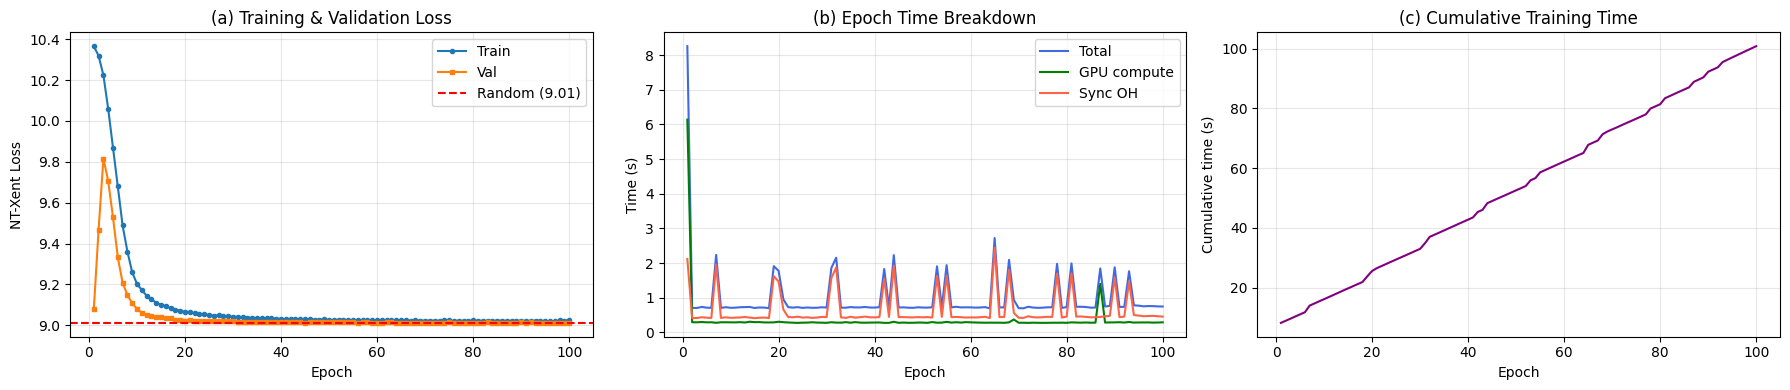

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', ms=3, label='Train')
axes[0].plot(history['epoch'], history['val_loss'],   's-', ms=3, label='Val')
axes[0].axhline(random_baseline, color='red', linestyle='--',
                label=f'Random ({random_baseline:.2f})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NT-Xent Loss')
axes[0].set_title('(a) Training & Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['epoch_time_s'],    label='Total',       color='royalblue')
axes[1].plot(history['epoch'], history['gpu_compute_s'],   label='GPU compute', color='green')
axes[1].plot(history['epoch'], history['sync_overhead_s'], label='Sync OH',     color='tomato')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Time (s)')
axes[1].set_title('(b) Epoch Time Breakdown')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch'], np.cumsum(history['epoch_time_s']), color='purple')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Cumulative time (s)')
axes[2].set_title('(c) Cumulative Training Time')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

## 10. Generate Embeddings

In [13]:
base_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
base_model.eval()

def generate_embeddings(model, fourier_mag, fourier_phase, id_list,
                         id_to_idx, device, batch_size=2048):
    """Encode all polygons using pre-computed Fourier features."""
    model.eval()
    all_embs = []
    t0 = time.perf_counter()
    with torch.no_grad():
        for i in tqdm(range(0, len(id_list), batch_size), desc='Encoding'):
            batch_ids  = id_list[i:i+batch_size]
            batch_idxs = [id_to_idx[pid] for pid in batch_ids]
            mag   = fourier_mag[batch_idxs]
            phase = fourier_phase[batch_idxs]
            feat  = np.concatenate([mag, phase], axis=1)
            batch = torch.from_numpy(feat).to(device, non_blocking=True)
            all_embs.append(model(batch).cpu().numpy())
    elapsed = time.perf_counter() - t0
    embs    = np.vstack(all_embs)
    print(f'Encoded {len(id_list):,} in {elapsed:.2f}s '
          f'({len(id_list)/elapsed:.0f} poly/s) | shape {embs.shape}')
    return embs, id_list, elapsed


print('Encoding index set (40K)...')
index_embeddings, index_ids_ordered, index_encode_time = generate_embeddings(
    base_model, fourier_mag, fourier_phase, index_ids, id_to_idx, DEVICE)

print('\nEncoding query set...')
query_embeddings, query_ids_ordered, query_encode_time = generate_embeddings(
    base_model, fourier_mag, fourier_phase, query_ids_with_gt, id_to_idx, DEVICE)

np.save(f'{OUTPUT_DIR}/index_embeddings.npy', index_embeddings)
np.save(f'{OUTPUT_DIR}/query_embeddings.npy', query_embeddings)
np.save(f'{OUTPUT_DIR}/index_ids.npy', np.array(index_ids_ordered))
np.save(f'{OUTPUT_DIR}/query_ids.npy', np.array(query_ids_ordered))
print('Embeddings saved.')

/tmp/ipykernel_3885623/4033578725.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))


Encoding index set (40K)...


Encoding: 100%|██████████| 20/20 [00:00<00:00, 399.82it/s]


Encoded 39,881 in 0.05s (771115 poly/s) | shape (39881, 64)

Encoding query set...


Encoding: 100%|██████████| 5/5 [00:00<00:00, 408.07it/s]

Encoded 9,391 in 0.01s (677463 poly/s) | shape (9391, 64)
Embeddings saved.


## 11. HNSW Indexing & Recall@K Evaluation

In [14]:
print(f'Building HNSW index with {HNSW_THREADS} threads...')
hnsw_index = hnswlib.Index(space='cosine', dim=EMBED_DIM)
hnsw_index.init_index(max_elements=len(index_ids_ordered),
                      ef_construction=HNSW_EF_CONSTR, M=HNSW_M)
hnsw_index.set_ef(HNSW_EF_SEARCH)
hnsw_index.set_num_threads(HNSW_THREADS)

t0 = time.perf_counter()
hnsw_index.add_items(index_embeddings, np.arange(len(index_ids_ordered)))
build_time = time.perf_counter() - t0
print(f'HNSW index built in {build_time:.2f}s')
hnsw_index.save_index(f'{OUTPUT_DIR}/hnsw_index.bin')

Building HNSW index with 32 threads...


HNSW index built in 0.45s


In [15]:
def evaluate_recall(hnsw_index, query_embs, query_ids, index_ids,
                    gt_dict, top_k_list):
    max_k        = max(top_k_list)
    recall_sums  = {k: 0.0 for k in top_k_list}
    query_times  = []
    label_to_id  = {i: pid for i, pid in enumerate(index_ids)}
    index_id_set = set(index_ids)
    n_valid      = 0
    for i, qid in enumerate(tqdm(query_ids, desc='Evaluating')):
        gt_set = gt_dict.get(qid, set()) & index_id_set
        if not gt_set:
            continue
        n_valid += 1
        t0 = time.perf_counter()
        labels, _ = hnsw_index.knn_query(query_embs[i:i+1], k=max_k)
        query_times.append(time.perf_counter() - t0)
        for k in top_k_list:
            top_k_ids = set(label_to_id[l] for l in labels[0][:k])
            recall_sums[k] += len(top_k_ids & gt_set) / len(gt_set)
    recall_scores = {k: recall_sums[k] / n_valid for k in top_k_list}
    print(f'Evaluated {n_valid:,} valid queries')
    return recall_scores, query_times


recall_scores, query_times = evaluate_recall(
    hnsw_index, query_embeddings, query_ids_ordered,
    index_ids_ordered, symmetric_gt, TOP_K
)

print('\n── Retrieval Results ────────────────────────────────────────')
for k, r in recall_scores.items():
    print(f'  Recall@{k:3d} : {r*100:.2f}%')
print(f'\nAvg query latency : {np.mean(query_times)*1000:.3f}ms')
print(f'P95 query latency : {np.percentile(query_times,95)*1000:.3f}ms')

pd.DataFrame({'K': list(recall_scores.keys()),
              'Recall@K': list(recall_scores.values())
}).to_csv(f'{OUTPUT_DIR}/recall_results.csv', index=False)
pd.DataFrame({'metric': ['index_encode_s','query_encode_s','hnsw_build_s',
                          'avg_query_ms','p95_query_ms'],
              'value':  [index_encode_time, query_encode_time, build_time,
                         np.mean(query_times)*1000,
                         np.percentile(query_times,95)*1000]
}).to_csv(f'{OUTPUT_DIR}/inference_timing.csv', index=False)

Evaluating: 100%|██████████| 9391/9391 [00:07<00:00, 1231.16it/s]

Evaluated 9,391 valid queries

── Retrieval Results ────────────────────────────────────────
  Recall@  1 : 0.00%
  Recall@  5 : 0.01%
  Recall@ 10 : 0.02%
  Recall@ 20 : 0.05%
  Recall@ 50 : 0.14%
  Recall@100 : 0.27%
  Recall@500 : 1.32%

Avg query latency : 0.449ms
P95 query latency : 0.567ms


## 12. Performance Plots

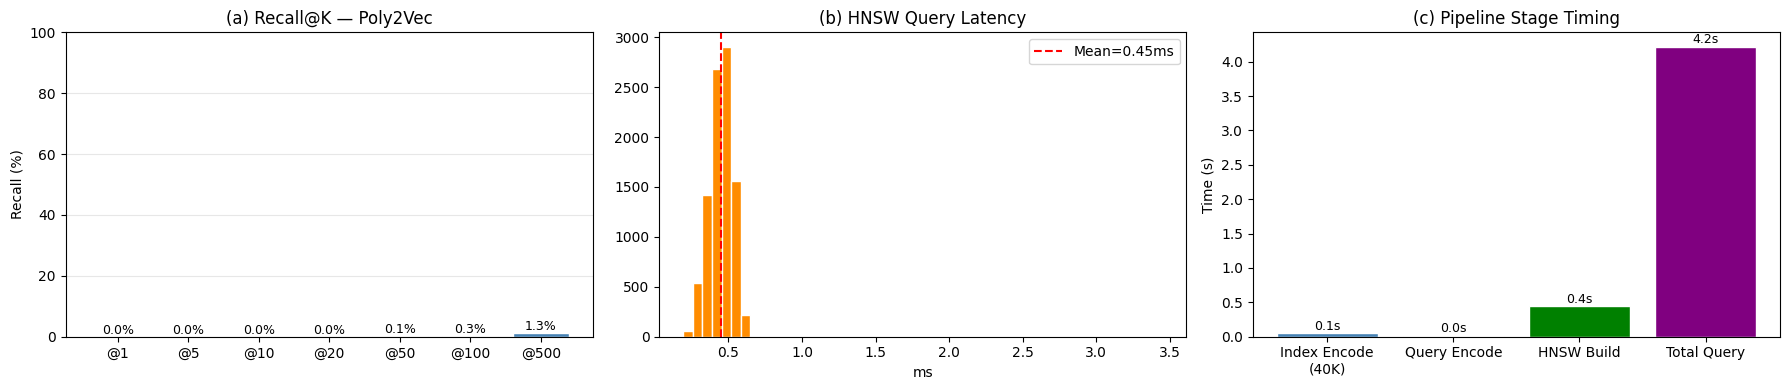

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ks      = list(recall_scores.keys())
recalls = [recall_scores[k]*100 for k in ks]
axes[0].bar([f'@{k}' for k in ks], recalls, color='steelblue', edgecolor='white')
axes[0].set_title('(a) Recall@K — Poly2Vec')
axes[0].set_ylabel('Recall (%)')
axes[0].set_ylim(0, 100); axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(recalls):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=9)

qt_ms = np.array(query_times)*1000
axes[1].hist(qt_ms, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(qt_ms.mean(), color='red', linestyle='--',
                label=f'Mean={qt_ms.mean():.2f}ms')
axes[1].set_title('(b) HNSW Query Latency')
axes[1].set_xlabel('ms'); axes[1].legend()

stages = ['Index Encode\n(40K)', 'Query Encode', 'HNSW Build', 'Total Query']
times  = [index_encode_time, query_encode_time, build_time, sum(query_times)]
axes[2].bar(stages, times,
            color=['steelblue','darkorange','green','purple'], edgecolor='white')
axes[2].set_title('(c) Pipeline Stage Timing')
axes[2].set_ylabel('Time (s)')
for i, v in enumerate(times):
    axes[2].text(i, v+0.05, f'{v:.1f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/performance_plots.png', dpi=150)
plt.show()

## 13. Comparison: Poly2Vec vs Method 1 (MLP Baseline)

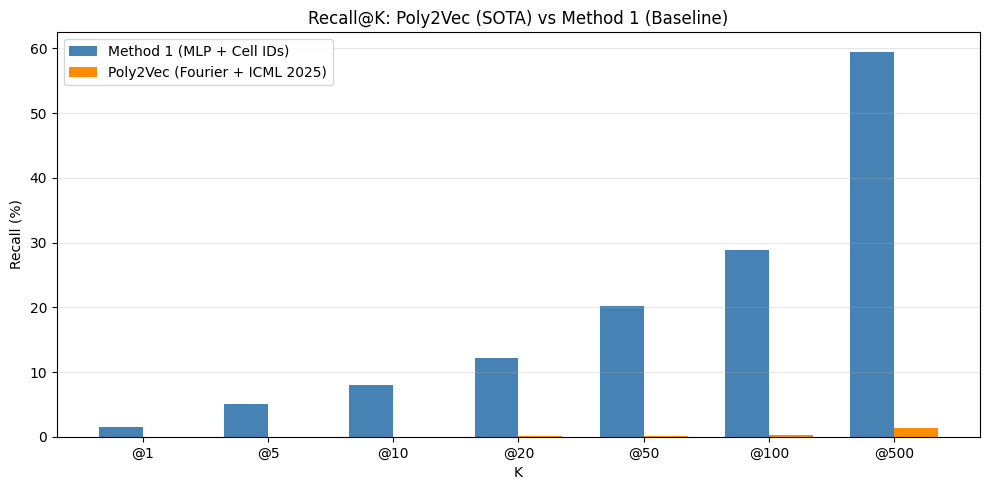

── Recall Comparison ────────────────────────────────────────
     K      Method1     Poly2Vec       Gain
     1        1.45%        0.00%     -1.45%
     5        5.02%        0.01%     -5.01%
    10        7.94%        0.02%     -7.92%
    20       12.11%        0.05%    -12.06%
    50       20.27%        0.14%    -20.13%
   100       28.90%        0.27%    -28.64%
   500       59.51%        1.32%    -58.19%


In [17]:
# Load Method 1 results for comparison
method1_recall_path = '/raid/ruban/hpmlproj/outputs_MLP_baseline/recall_results.csv' 

if os.path.exists(method1_recall_path):
    m1_df = pd.read_csv(method1_recall_path)
    m1_recall = dict(zip(m1_df['K'], m1_df['Recall@K']))

    # Compare on common K values
    common_k = sorted(set(ks) & set(m1_recall.keys()))

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(common_k))
    width = 0.35

    m1_vals   = [m1_recall[k]*100 for k in common_k]
    p2v_vals  = [recall_scores[k]*100 for k in common_k]

    ax.bar(x - width/2, m1_vals,  width, label='Method 1 (MLP + Cell IDs)', color='steelblue')
    ax.bar(x + width/2, p2v_vals, width, label='Poly2Vec (Fourier + ICML 2025)', color='darkorange')

    ax.set_xticks(x)
    ax.set_xticklabels([f'@{k}' for k in common_k])
    ax.set_xlabel('K')
    ax.set_ylabel('Recall (%)')
    ax.set_title('Recall@K: Poly2Vec (SOTA) vs Method 1 (Baseline)')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/comparison_vs_method1.png', dpi=150)
    plt.show()

    print('── Recall Comparison ────────────────────────────────────────')
    print(f'{"K":>6s} {"Method1":>12s} {"Poly2Vec":>12s} {"Gain":>10s}')
    for k in common_k:
        m1  = m1_recall[k]*100
        p2v = recall_scores[k]*100
        gain = p2v - m1
        print(f'{k:>6d} {m1:>11.2f}% {p2v:>11.2f}% {gain:>+9.2f}%')
else:
    print('Method 1 results not found — skipping comparison plot.')

## 14. Final Summary

In [18]:
print('=' * 70)
print('  POLY2VEC (ICML 2025) — DGX Final Summary')
print('=' * 70)
print(f'\n── Platform ──────────────────────────────────────────────────────')
print(f'  Server : DGX A100  |  GPUs: {NUM_GPUS}× A100-80GB  |  CPUs: {NUM_CPUS}')
print(f'\n── Configuration ─────────────────────────────────────────────────')
print(f'  Input      : 2D Fourier transform of WKT polygon coords')
print(f'  Features   : {fourier_mag.shape[1]*2}-dim (mag {fourier_mag.shape[1]} + phase {fourier_mag.shape[1]})')
print(f'  Embed dim  : {EMBED_DIM} | D_hid: {D_HID}')
print(f'  Loss       : NT-Xent (T={TEMPERATURE}, {BATCH_SIZE-1} negatives/anchor)')
print(f'  Epochs     : {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'\n── Training ──────────────────────────────────────────────────────')
avg_gpu  = np.mean(history['gpu_compute_s'])
avg_sync = np.mean(history['sync_overhead_s'])
avg_tot  = np.mean(history['epoch_time_s'])
print(f'  Best val loss           : {best_val_loss:.4f}')
print(f'  Random baseline         : {random_baseline:.4f}')
print(f'  Gap below random        : {random_baseline - best_val_loss:.4f}')
print(f'  Avg GPU compute/epoch   : {avg_gpu:.2f}s ({avg_gpu/avg_tot*100:.1f}%)')
print(f'  Avg sync overhead/epoch : {avg_sync:.2f}s ({avg_sync/avg_tot*100:.1f}%)')
print(f'  Total training time     : {sum(history["epoch_time_s"]):.1f}s')
print(f'\n── Retrieval (Jaccard GT) ────────────────────────────────────────')
for k, r in recall_scores.items():
    print(f'  Recall@{k:3d} : {r*100:.2f}%')
print(f'\n── Inference Timing ──────────────────────────────────────────────')
print(f'  Fourier pre-compute     : cached')
print(f'  Index encoding (40K)    : {index_encode_time:.2f}s')
print(f'  Query encoding          : {query_encode_time:.2f}s')
print(f'  HNSW build              : {build_time:.2f}s')
print(f'  Avg query latency       : {np.mean(query_times)*1000:.3f}ms')
print(f'  P95 query latency       : {np.percentile(query_times,95)*1000:.3f}ms')
print(f'\n── Output Files ──────────────────────────────────────────────────')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        print(f'  {fname:<50s} {os.path.getsize(fpath)/1024:8.1f} KB')
print('\nDone!')

  POLY2VEC (ICML 2025) — DGX Final Summary

── Platform ──────────────────────────────────────────────────────
  Server : DGX A100  |  GPUs: 8× A100-80GB  |  CPUs: 256

── Configuration ─────────────────────────────────────────────────
  Input      : 2D Fourier transform of WKT polygon coords
  Features   : 420-dim (mag 210 + phase 210)
  Embed dim  : 64 | D_hid: 256
  Loss       : NT-Xent (T=0.07, 4095 negatives/anchor)
  Epochs     : 100 | Batch: 4096 | LR: 0.0003

── Training ──────────────────────────────────────────────────────
  Best val loss           : 9.0117
  Random baseline         : 9.0109
  Gap below random        : -0.0008
  Avg GPU compute/epoch   : 0.36s (35.2%)
  Avg sync overhead/epoch : 0.65s (64.8%)
  Total training time     : 100.8s

── Retrieval (Jaccard GT) ────────────────────────────────────────
  Recall@  1 : 0.00%
  Recall@  5 : 0.01%
  Recall@ 10 : 0.02%
  Recall@ 20 : 0.05%
  Recall@ 50 : 0.14%
  Recall@100 : 0.27%
  Recall@500 : 1.32%

── Inference Timing 